### imports and settings

In [1]:
import pandas as pd
from topic_modeling_utils import (
    run_tfidf, 
    run_nmf_and_display, 
    get_abstracts_with_topics, 
    get_topic_stats, 
    plot_quarterly_distribution, 
    get_top_documents_per_topic
)

In [2]:
abstracts_df = pd.read_pickle("abstracts_df.pkl")

### running a TF-IDF vectorizer

In [5]:
vectorizer, tfidf_df = run_tfidf(abstracts_df["text_cleaned"])
#tfidf_df

In [7]:
vectorizer, tfidf_df = run_tfidf(abstracts_df["text_cleaned"], stop_words='english', min_df=0.05, max_df=0.2)
#tfidf_df

### non-negative matrix factorization and topic analysis

In [9]:
W, H = run_nmf_and_display(tfidf_df, vectorizer, n_topics=5, num_words=10)

Topic 1: network, variation, evolution, host, process, animal, ecology, niche, selection, rate
Topic 2: temperature, climate, shift, range, rate, condition, time, variability, year, variation
Topic 3: forest, tree, growth, disturbance, density, climate, carbon, productivity, year, survival
Topic 4: diversity, biodiversity, relationship, stability, function, richness, scale, loss, conservation, area
Topic 5: soil, carbon, biomass, decrease, condition, influence, process, availability, group, experiment


In [10]:
my_topics = ['evolution', 'climate change', 'forests', 'biodiversity', 'soils']

In [11]:
abstracts_topics = get_abstracts_with_topics(abstracts_df, W, my_topics)
stats = get_topic_stats(abstracts_topics)
print(stats)

                count  percent
dominant_topic                
evolution         376    42.06
biodiversity      240    26.85
climate change    131    14.65
forests            81     9.06
soils              66     7.38


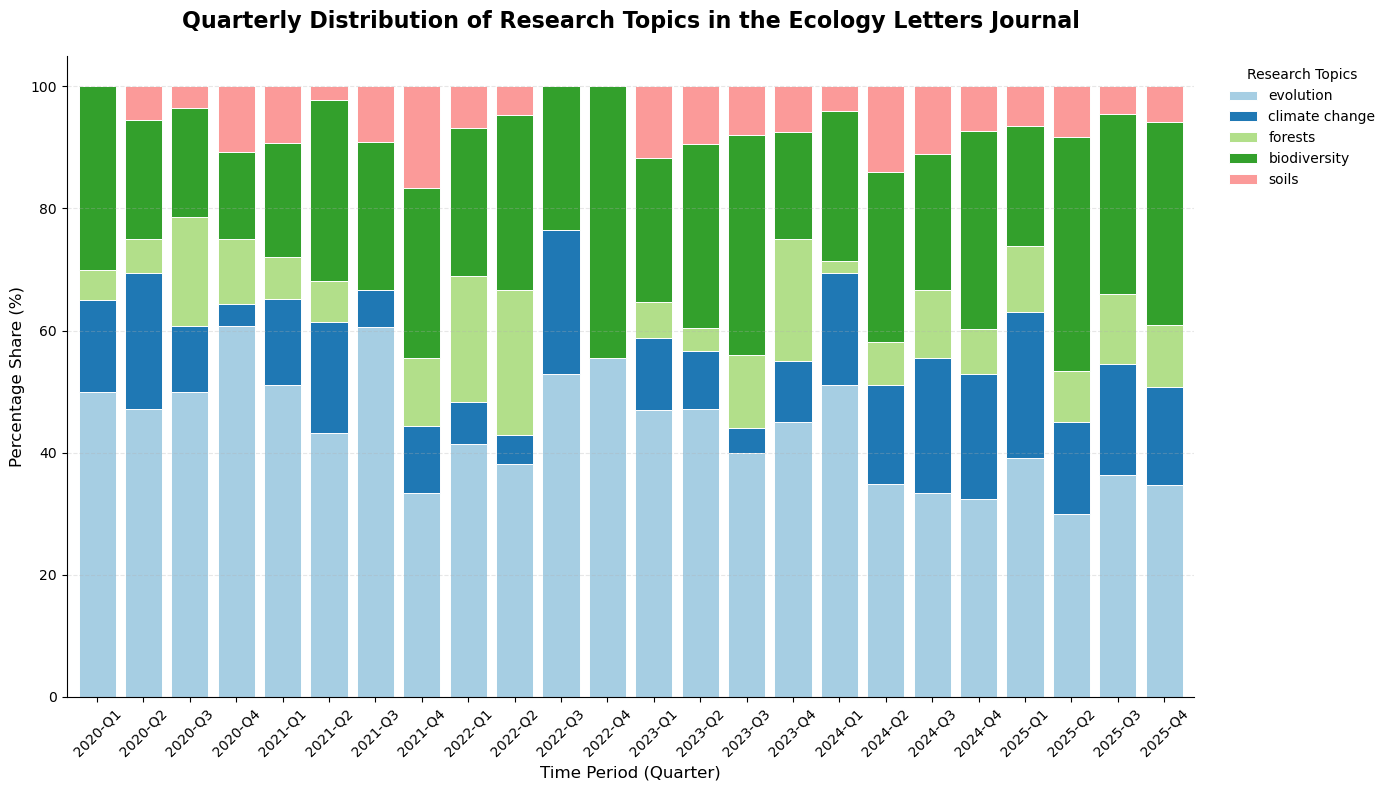

In [12]:
quarterly_table = plot_quarterly_distribution(abstracts_topics, my_topics)

In [13]:
get_top_documents_per_topic(abstracts_topics, my_topics)

TOP DOCUMENTS FOR TOPIC: EVOLUTION
Score: 0.1208
Title: Genetic correlations and ecological networks shape coevolving mutualisms.
Abstract: Ecological interactions shape the evolution of multiple species traits in populations. These traits are often linked to each other through genetic correlations, affecting how each trait evolves through selection imposed by interacting partners. Here, we integrate quantitative genetics, coevolutionary theory and network science to explore how trait correlations affect the coevolution of mutualistic species not only in pairs of species but also in species-rich networks across space. We show that g...
--------------------------------------------------


TOP DOCUMENTS FOR TOPIC: CLIMATE CHANGE
Score: 0.3477
Title: Impacts of Weather Anomalies and Climate on Plant Disease.
Abstract: Predicting the effects of climate change on plant disease is critical for protecting ecosystems and food production. Here, we show how disease pressure responds to short-ter

In [12]:
abstracts_topics.to_pickle("abstracts_topics.pkl")